# 07 - Seed Sensitivity Analysis
Aggregate MLP/LSTM/PatchTST results across multiple seeds and visualize mean ? std.


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('saved_results')
SEEDS = [42, 123, 2024]
METRICS = [
    'overall_mae',
    'warm_mae',
    'cold_mae',
    'overall_cvrmse',
    'overall_wape'
]
DISPLAY_STRATEGIES = [
    '1. FTL', '2. Personalized-FL', '3. Progressive Unfreezing',
    '4. Instance-TL', '5. Fed-SimTL', '6. FedMetaTL'
]

print('Results dir:', RESULTS_DIR.resolve())
print('Seeds:', SEEDS)


Results dir: E:\PhD\FTL_Smart_Buildings_Energy_Prediction\saved_results
Seeds: [42, 123, 2024]


In [3]:
# Load standardized seed summaries
pattern = re.compile(r'^(mlp|lstm|patchtst)_seed_(\d+)_summary\.csv$', re.IGNORECASE)
frames = []
for p in RESULTS_DIR.glob('*_seed_*_summary.csv'):
    m = pattern.match(p.name)
    if not m:
        continue
    model = m.group(1).upper().replace('PATCHTST', 'PatchTST')
    seed = int(m.group(2))
    if seed not in SEEDS:
        continue
    df = pd.read_csv(p)
    if 'model' not in df.columns:
        df['model'] = model
    if 'seed' not in df.columns:
        df['seed'] = seed
    frames.append(df)

if not frames:
    raise FileNotFoundError('No standardized seed summary CSVs found. Run export cells in 03/04/06 first.')

all_seed_results = pd.concat(frames, ignore_index=True)
all_seed_results['model'] = all_seed_results['model'].replace({'MLP':'MLP','LSTM':'LSTM','PATCHTST':'PatchTST'})
all_seed_results = all_seed_results.sort_values(['model','strategy','seed']).reset_index(drop=True)
print('Loaded rows:', len(all_seed_results))
display(all_seed_results.head(20))


Loaded rows: 81


,model,seed,strategy,overall_mae,warm_mae,cold_mae,overall_cvrmse,overall_wape
0,LSTM,42,0. Local-only,0.332223,0.243809,0.685880,30.446616,22.537857
1,LSTM,123,0. Local-only,0.298146,0.237475,0.540831,29.337522,21.489799
2,LSTM,2024,0. Local-only,0.298596,0.238627,0.538472,30.118283,22.501462
3,LSTM,42,1. FTL,0.322613,0.302968,0.401195,59.792459,55.545916
4,LSTM,123,1. FTL,0.304517,0.292606,0.352159,49.796799,45.853382
5,LSTM,2024,1. FTL,0.223464,0.213984,0.261382,26.566649,21.948485
6,LSTM,42,1b. FedAvg (No Pretrain),0.312560,0.303010,0.350758,35.617697,30.090985
7,LSTM,123,1b. FedAvg (No Pretrain),0.581098,0.549640,0.706930,109.581610,104.458350
8,LSTM,2024,1b. FedAvg (No Pretrain),0.575669,0.546364,0.692885,97.593642,92.789478
9,LSTM,42,2. Personalized-FL,0.670397,0.601822,0.944699,48.525902,43.336353


In [4]:
# Aggregate mean/std over seeds
required_cols = {'model', 'seed', 'strategy', *METRICS}
missing = [c for c in required_cols if c not in all_seed_results.columns]
if missing:
    raise ValueError(f'Missing columns for aggregation: {missing}')

for metric in METRICS:
    agg = (all_seed_results
           .groupby(['model', 'strategy'])[metric]
           .agg(['mean', 'std', 'count'])
           .reset_index())

    agg.columns = [
        'model',
        'strategy',
        f'{metric}_mean',
        f'{metric}_std',
        'n_seeds'
    ]

    agg = agg[agg['strategy'].isin(DISPLAY_STRATEGIES)]
    agg = agg.sort_values(['model', 'strategy']).reset_index(drop=True)

    print(f'\nMetric: {metric}')
    display(agg)

    out_path = RESULTS_DIR / f'seed_agg_{metric}.csv'
    agg.to_csv(out_path, index=False)
    print('Saved:', out_path)


Metric: overall_mae


,model,strategy,overall_mae_mean,overall_mae_std,n_seeds
0,LSTM,1. FTL,0.283531,0.052801,3
1,LSTM,2. Personalized-FL,0.696555,0.087955,3
2,LSTM,3. Progressive Unfreezing,0.300293,0.052708,3
3,LSTM,4. Instance-TL,0.129910,0.025483,3
4,LSTM,5. Fed-SimTL,0.118331,0.005138,3
5,LSTM,6. FedMetaTL,0.288302,0.059124,3
6,MLP,1. FTL,0.298988,0.061260,3
7,MLP,2. Personalized-FL,0.523703,0.045149,3
8,MLP,3. Progressive Unfreezing,0.298253,0.046654,3
9,MLP,4. Instance-TL,0.160933,0.007336,3


Saved: saved_results\seed_agg_overall_mae.csv

Metric: warm_mae


,model,strategy,warm_mae_mean,warm_mae_std,n_seeds
0,LSTM,1. FTL,0.269853,0.048660,3
1,LSTM,2. Personalized-FL,0.658097,0.130614,3
2,LSTM,3. Progressive Unfreezing,0.287781,0.052599,3
3,LSTM,4. Instance-TL,0.122996,0.022675,3
4,LSTM,5. Fed-SimTL,0.109043,0.006710,3
5,LSTM,6. FedMetaTL,0.276680,0.054259,3
6,MLP,1. FTL,0.288855,0.063083,3
7,MLP,2. Personalized-FL,0.514031,0.052050,3
8,MLP,3. Progressive Unfreezing,0.293952,0.046079,3
9,MLP,4. Instance-TL,0.164594,0.012696,3


Saved: saved_results\seed_agg_warm_mae.csv

Metric: cold_mae


...

Saved: saved_results\seed_agg_cold_mae.csv

Metric: overall_cvrmse


,model,strategy,overall_cvrmse_mean,overall_cvrmse_std,n_seeds
0,LSTM,1. FTL,45.385302,17.046542,3
1,LSTM,2. Personalized-FL,54.886132,6.250993,3
2,LSTM,3. Progressive Unfreezing,36.649546,6.923783,3
3,LSTM,4. Instance-TL,19.463470,2.935482,3
4,LSTM,5. Fed-SimTL,15.504983,1.043251,3
5,LSTM,6. FedMetaTL,43.209059,8.676775,3
6,MLP,1. FTL,33.140590,5.413028,3
7,MLP,2. Personalized-FL,52.867633,4.673122,3
8,MLP,3. Progressive Unfreezing,34.378791,4.384268,3
9,MLP,4. Instance-TL,19.221102,0.396403,3


Saved: saved_results\seed_agg_overall_cvrmse.csv

Metric: overall_wape


,model,strategy,overall_wape_mean,overall_wape_std,n_seeds
0,LSTM,1. FTL,41.115928,17.292468,3
1,LSTM,2. Personalized-FL,49.326632,6.024217,3
2,LSTM,3. Progressive Unfreezing,30.907494,7.259435,3
3,LSTM,4. Instance-TL,14.576125,3.066916,3
4,LSTM,5. Fed-SimTL,11.797421,0.896701,3
5,LSTM,6. FedMetaTL,37.923849,8.920136,3
6,MLP,1. FTL,27.687571,5.176466,3
7,MLP,2. Personalized-FL,45.740332,5.041339,3
8,MLP,3. Progressive Unfreezing,29.189316,4.104375,3
9,MLP,4. Instance-TL,15.370060,0.562704,3


Saved: saved_results\seed_agg_overall_wape.csv


In [5]:
# Publication table: average +/- standard deviation over seeds
METRIC_LABELS = {
    'overall_mae': 'Overall MAE',
    'warm_mae': 'Warm MAE',
    'cold_mae': 'Cold MAE',
    'overall_cvrmse': 'CVRMSE (%)',
    'overall_wape': 'WAPE (%)',
}

def mean_std_text(mean, std, digits=3):
    if pd.isna(mean):
        return ''
    if pd.isna(std):
        return f'{mean:.{digits}f}'
    return f'{mean:.{digits}f} +/- {std:.{digits}f}'

summary_rows = []
for (model, strategy), d in all_seed_results.groupby(['model', 'strategy']):
    row = {
        'Model': model,
        'Strategy': strategy,
        'Seeds': ', '.join(str(int(s)) for s in sorted(d['seed'].dropna().unique())),
        'N seeds': int(d['seed'].nunique()),
    }
    for metric in METRICS:
        row[METRIC_LABELS[metric]] = mean_std_text(d[metric].mean(), d[metric].std(ddof=1), digits=3)
        row[f'{metric}_mean'] = d[metric].mean()
        row[f'{metric}_std'] = d[metric].std(ddof=1)
    summary_rows.append(row)

seed_mean_std_table = pd.DataFrame(summary_rows)
model_order = ['MLP', 'LSTM', 'PatchTST']
strategy_order = [
    'C. Centralized',
    '0. Local-only',
    '1b. FedAvg (No Pretrain)',
    '1. FTL',
    '2. Personalized-FL',
    '3. Progressive Unfreezing',
    '4. Instance-TL',
    '5. Fed-SimTL',
    '6. FedMetaTL',
]
seed_mean_std_table['Model'] = pd.Categorical(seed_mean_std_table['Model'], categories=model_order, ordered=True)
seed_mean_std_table['Strategy'] = pd.Categorical(seed_mean_std_table['Strategy'], categories=strategy_order, ordered=True)
seed_mean_std_table = seed_mean_std_table.sort_values(['Model', 'Strategy']).reset_index(drop=True)
seed_mean_std_table['Model'] = seed_mean_std_table['Model'].astype(str)
seed_mean_std_table['Strategy'] = seed_mean_std_table['Strategy'].astype(str)

display_cols = ['Model', 'Strategy', 'Seeds', 'N seeds'] + list(METRIC_LABELS.values())
display(seed_mean_std_table[display_cols])

csv_path = RESULTS_DIR / 'seed_mean_std_publication_table.csv'
tex_path = RESULTS_DIR / 'seed_mean_std_publication_table.tex'
seed_mean_std_table[display_cols].to_csv(csv_path, index=False)
latex_df = seed_mean_std_table[display_cols].copy()
for col in METRIC_LABELS.values():
    latex_df[col] = latex_df[col].str.replace('+/-', r'$\\pm$', regex=False)

def latex_escape(value):
    text = str(value)
    text = text.replace('\\', r'\\textbackslash{}')
    for old, new in {'_': r'\\_', '%': r'\\%', '&': r'\\&', '#': r'\\#'}.items():
        text = text.replace(old, new)
    return text.replace('$\\\\pm$', r'$\\pm$')

with open(tex_path, 'w', encoding='utf-8') as f:
    f.write('\\begin{table}[htbp]\n\\centering\n')
    f.write('\\caption{Average performance across random seeds reported as mean $\\\\pm$ standard deviation.}\n')
    f.write('\\label{tab:seed_mean_std_results}\n')
    f.write('\\begin{tabular}{llrrccccc}\n\\hline\n')
    f.write(' & '.join(latex_escape(c) for c in display_cols) + r' \\ \hline' + '\n')
    for _, row in latex_df.iterrows():
        f.write(' & '.join(latex_escape(row[c]) for c in display_cols) + r' \\' + '\n')
    f.write('\\hline\n\\end{tabular}\n\\end{table}\n')

print('Saved:', csv_path)
print('Saved:', tex_path)

expected = set(SEEDS)
available = (all_seed_results.groupby(['model', 'strategy'])['seed']
             .apply(lambda s: set(int(x) for x in s.dropna().unique()))
             .reset_index(name='available_seeds'))
missing_seed_rows = []
for _, r in available.iterrows():
    missing = sorted(expected - r['available_seeds'])
    if missing:
        missing_seed_rows.append({
            'model': r['model'],
            'strategy': r['strategy'],
            'missing_seeds': missing,
        })

if missing_seed_rows:
    print('\nWarning: some model/strategy rows do not include all requested seeds:')
    display(pd.DataFrame(missing_seed_rows))


,Model,Strategy,Seeds,N seeds,Overall MAE,Warm MAE,Cold MAE,CVRMSE (%),WAPE (%)
0,MLP,C. Centralized,"42, 123, 2024",3,0.137 +/- 0.017,0.124 +/- 0.017,0.186 +/- 0.022,16.443 +/- 1.509,12.625 +/- 1.417
1,MLP,0. Local-only,"42, 123, 2024",3,0.263 +/- 0.005,0.193 +/- 0.006,0.542 +/- 0.008,28.966 +/- 0.477,22.737 +/- 0.433
2,MLP,1b. FedAvg (No Pretrain),"42, 123, 2024",3,0.326 +/- 0.028,0.309 +/- 0.025,0.393 +/- 0.053,39.133 +/- 3.157,33.671 +/- 3.457
3,MLP,1. FTL,"42, 123, 2024",3,0.299 +/- 0.061,0.289 +/- 0.063,0.340 +/- 0.056,33.141 +/- 5.413,27.688 +/- 5.176
4,MLP,2. Personalized-FL,"42, 123, 2024",3,0.524 +/- 0.045,0.514 +/- 0.052,0.562 +/- 0.024,52.868 +/- 4.673,45.740 +/- 5.041
5,MLP,3. Progressive Unfreezing,"42, 123, 2024",3,0.298 +/- 0.047,0.294 +/- 0.046,0.315 +/- 0.049,34.379 +/- 4.384,29.189 +/- 4.104
6,MLP,4. Instance-TL,"42, 123, 2024",3,0.161 +/- 0.007,0.165 +/- 0.013,0.146 +/- 0.021,19.221 +/- 0.396,15.370 +/- 0.563
7,MLP,5. Fed-SimTL,"42, 123, 2024",3,0.150 +/- 0.004,0.151 +/- 0.005,0.148 +/- 0.031,17.948 +/- 1.000,14.042 +/- 0.720
8,MLP,6. FedMetaTL,"42, 123, 2024",3,0.306 +/- 0.031,0.301 +/- 0.033,0.325 +/- 0.026,32.575 +/- 1.313,26.993 +/- 1.047
9,LSTM,C. Centralized,"42, 123, 2024",3,0.116 +/- 0.016,0.114 +/- 0.016,0.125 +/- 0.016,17.596 +/- 3.417,13.088 +/- 3.113


Saved: saved_results\seed_mean_std_publication_table.csv
Saved: saved_results\seed_mean_std_publication_table.tex


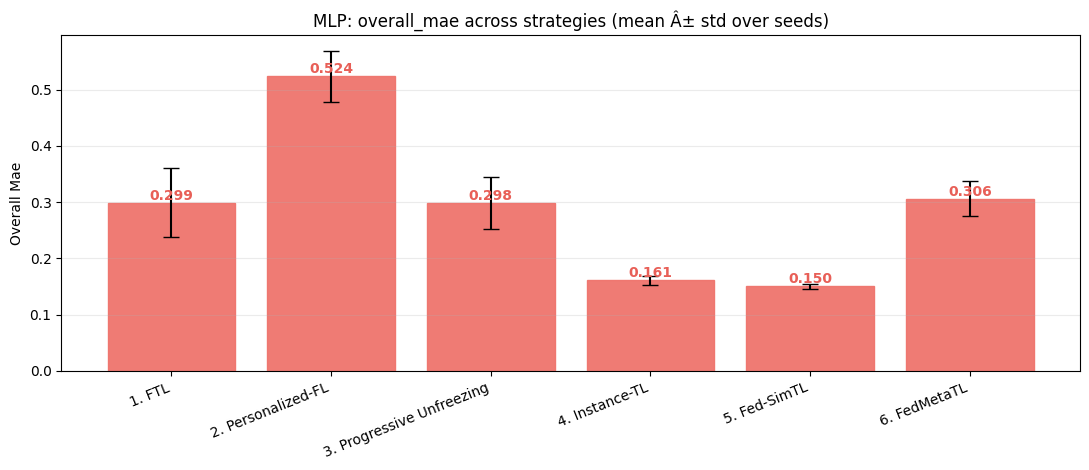

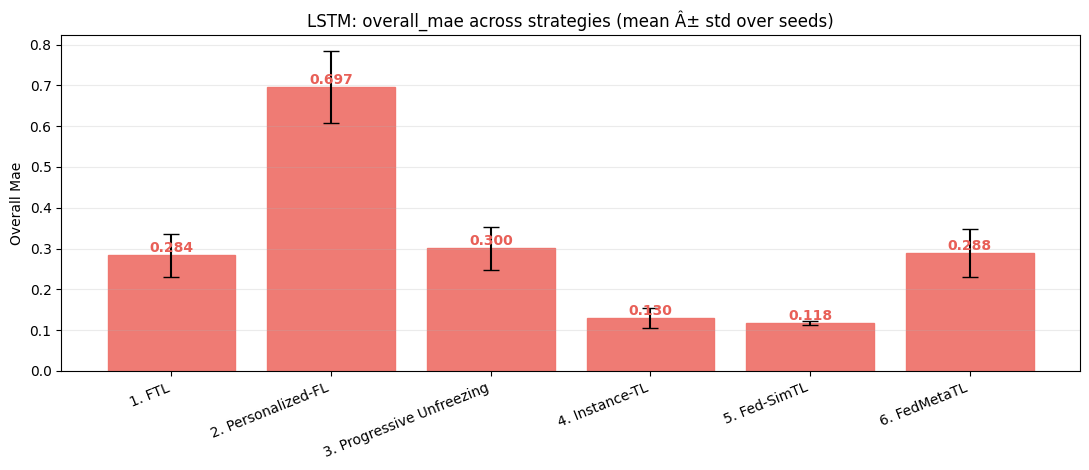

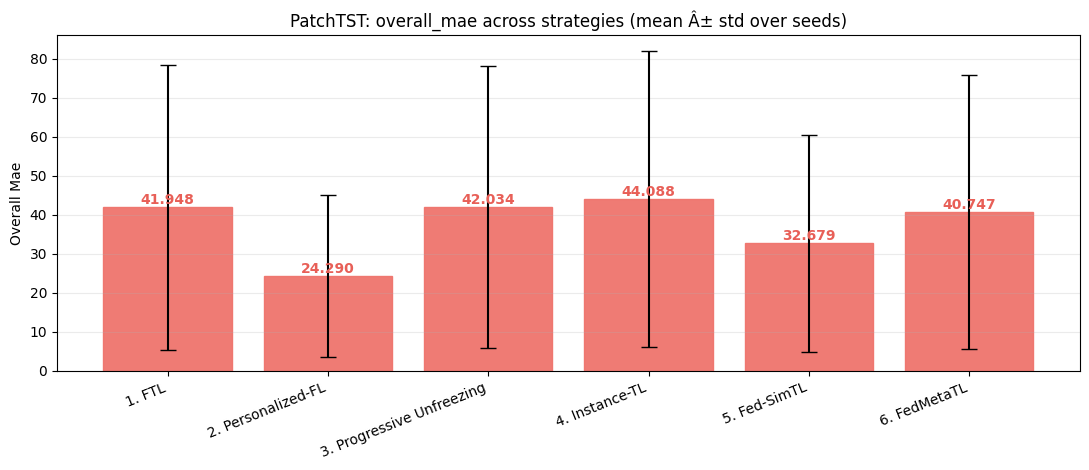

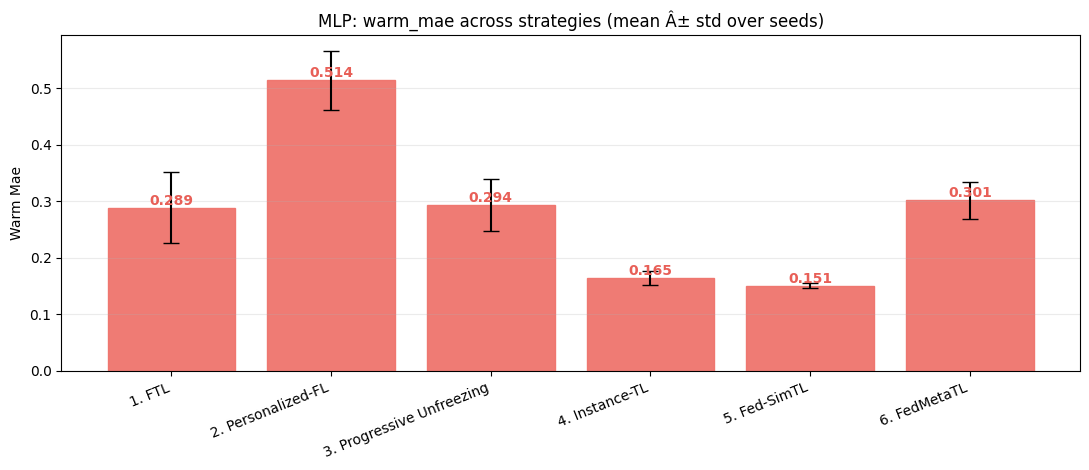

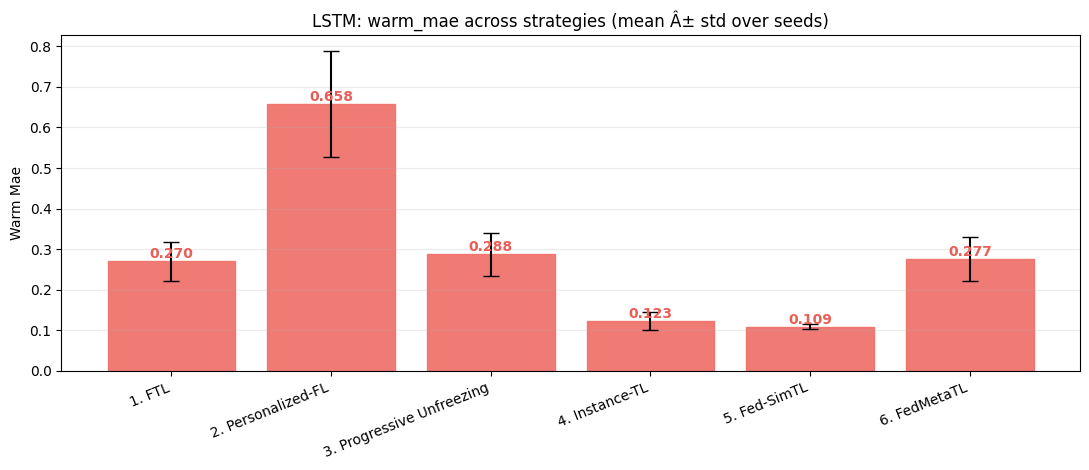

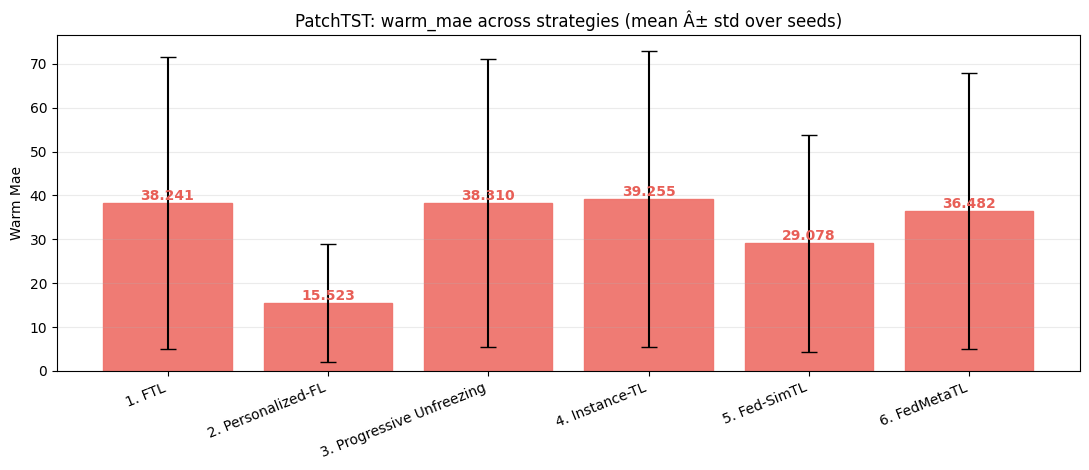

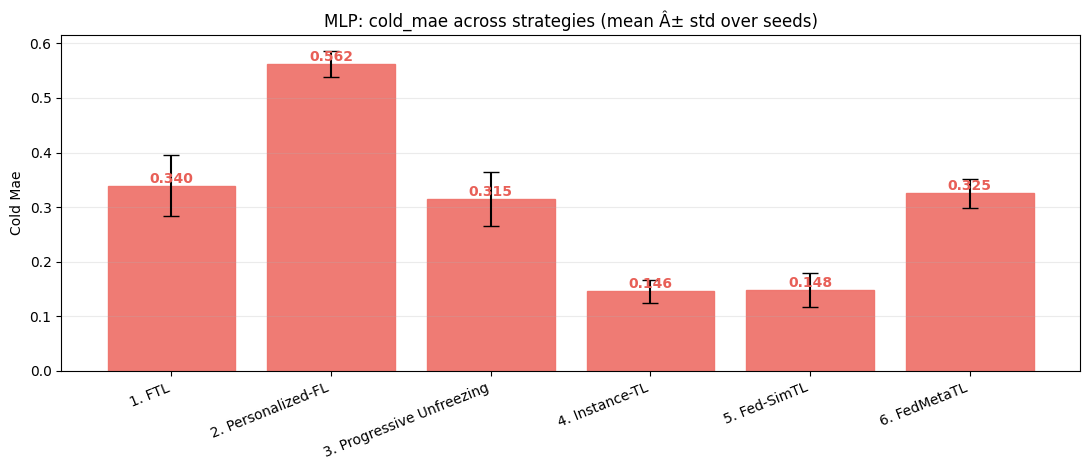

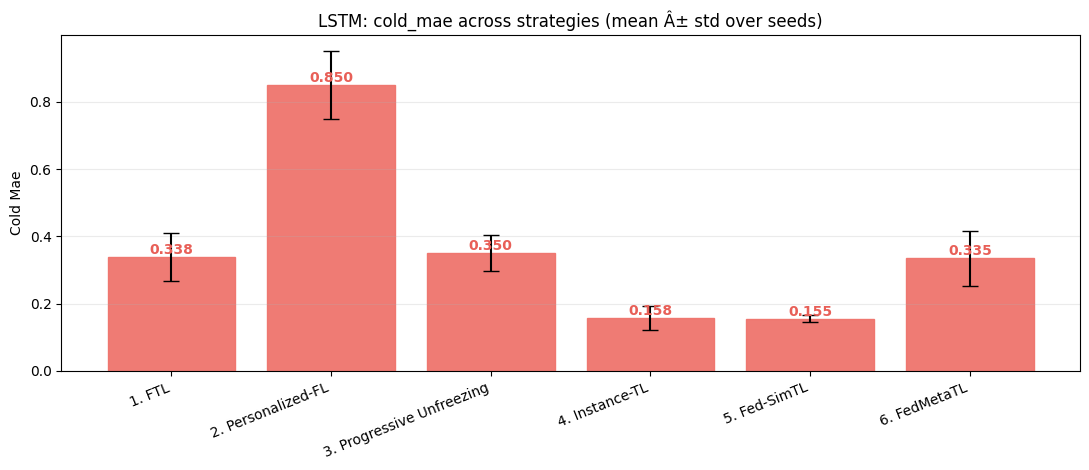

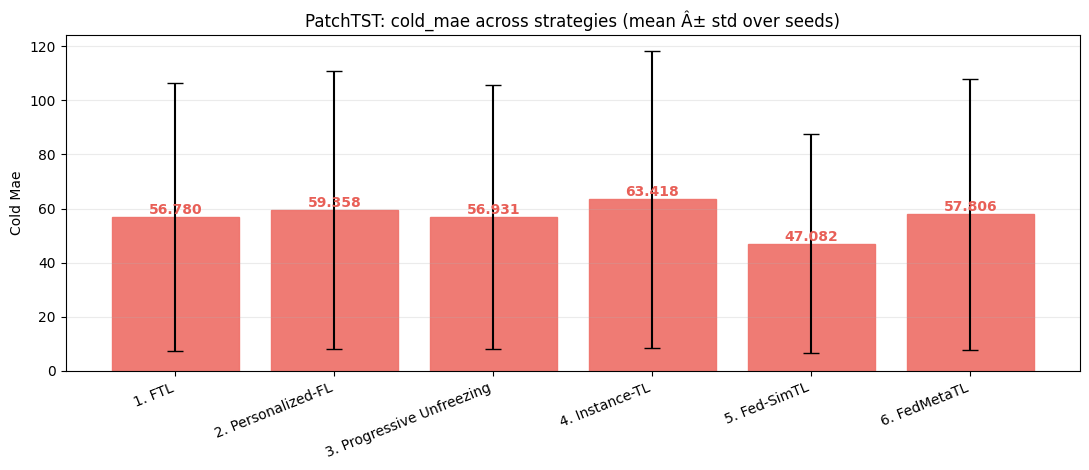

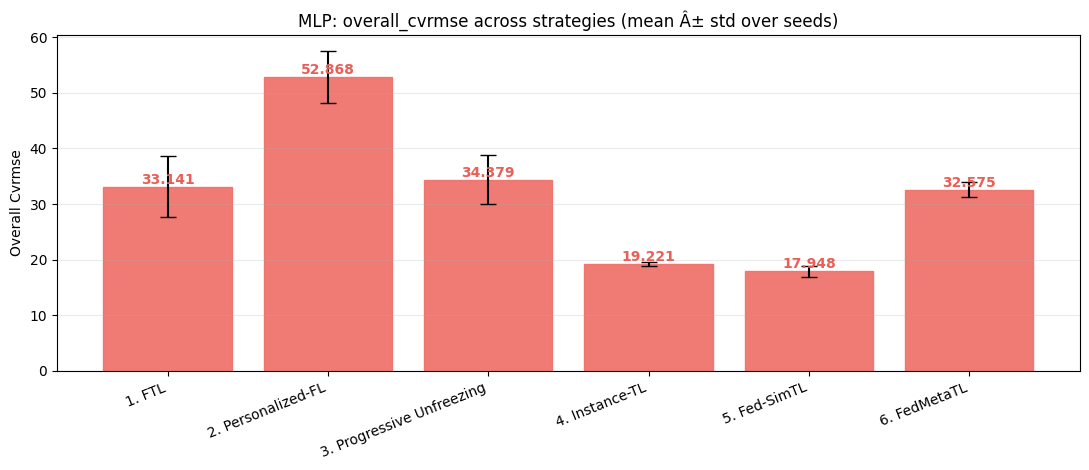

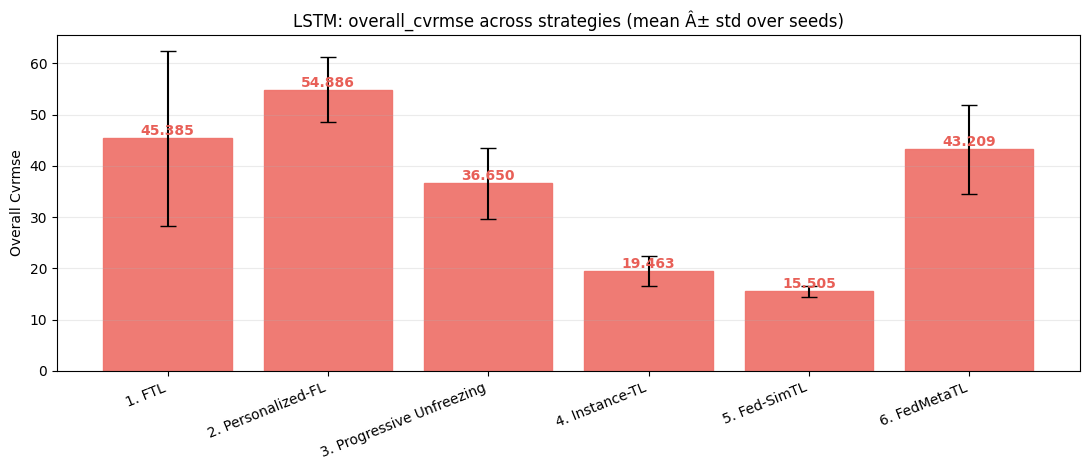

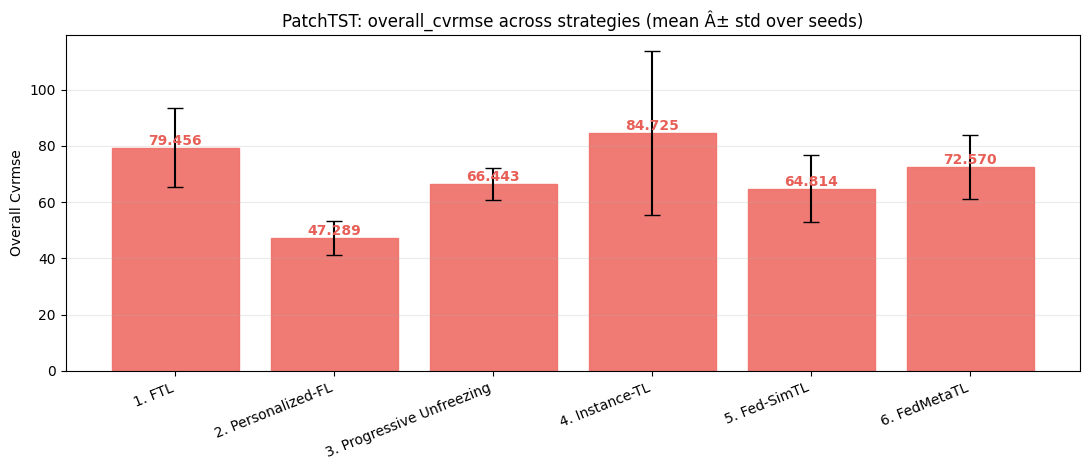

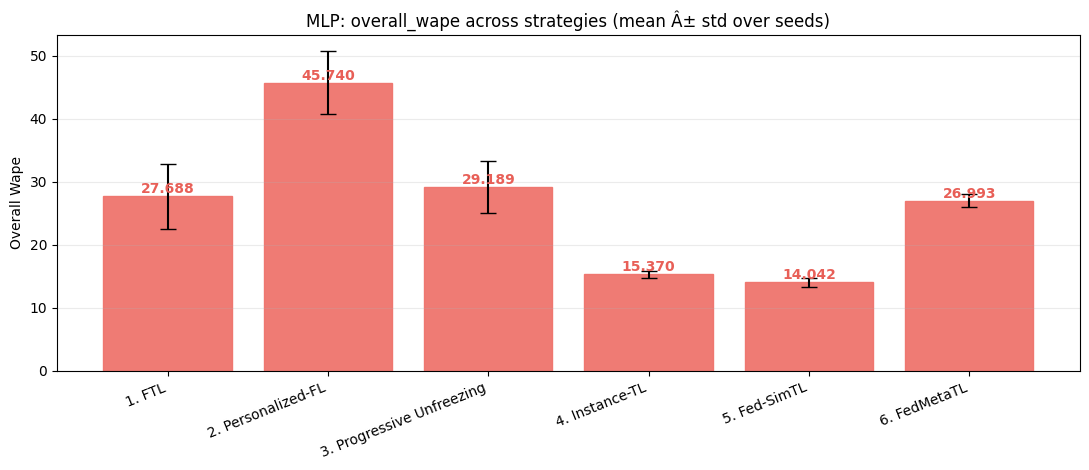

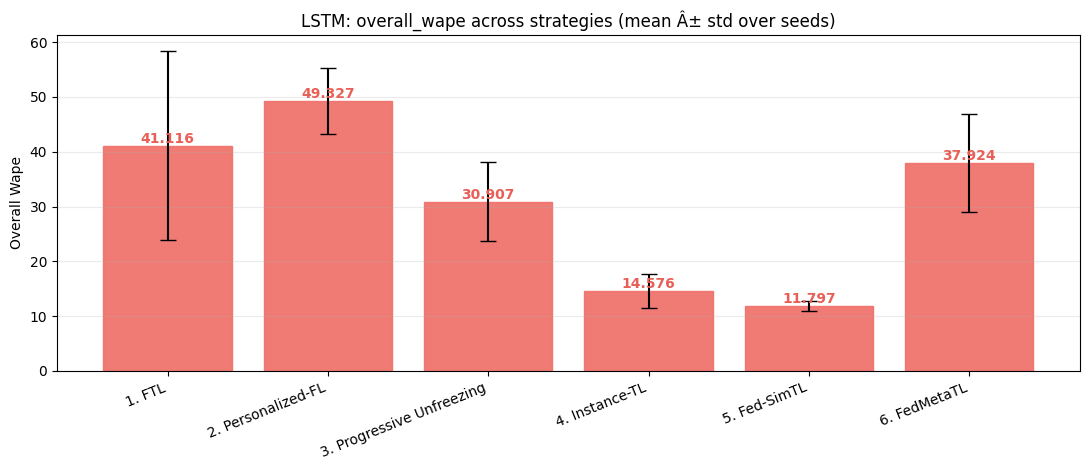

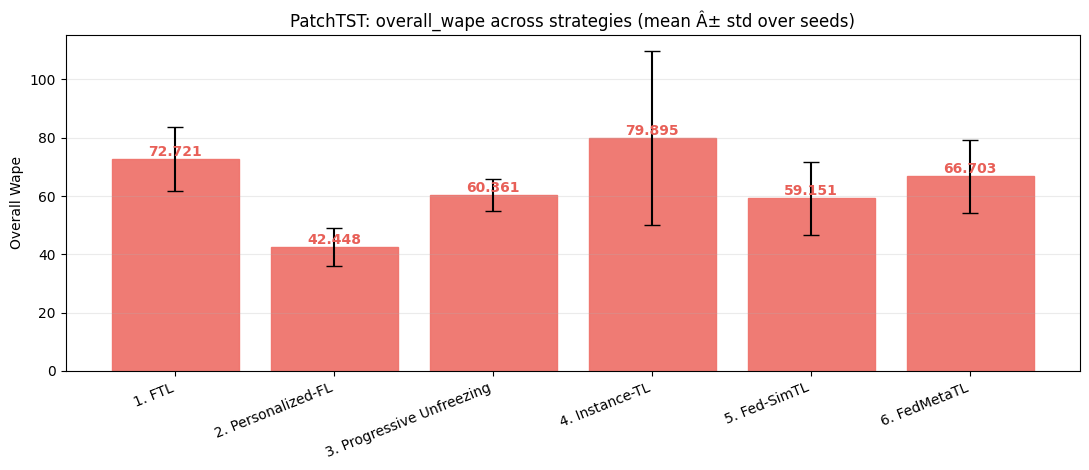

In [6]:

# Plot 1: per-model bars over strategies (mean Â± std across seeds)

models = ['MLP', 'LSTM', 'PatchTST']

for metric in METRICS:

    # Load the corresponding aggregated dataframe
    agg = pd.read_csv(RESULTS_DIR / f'seed_agg_{metric}.csv')

    for model in models:

        d = agg[agg['model'] == model].copy()

        if d.empty:
            continue

        d['strategy'] = pd.Categorical(
            d['strategy'],
            categories=DISPLAY_STRATEGIES,
            ordered=True
        )

        d = d.sort_values('strategy')

        plt.figure(figsize=(11, 4.8))

        x = np.arange(len(d))
        y = d[f'{metric}_mean'].values
        e = np.nan_to_num(d[f'{metric}_std'].values, nan=0.0)

        plt.bar(
            x,
            y,
            yerr=e,
            capsize=6,
            color='#ef746c',
            edgecolor='#ef746c',
            alpha=0.95
        )

        # value labels
        for xi, yi in zip(x, y):
            plt.text(
                xi,
                yi,
                f'{yi:.3f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='#e85f57',
                fontweight='bold'
            )

        plt.xticks(x, d['strategy'], rotation=22, ha='right')

        plt.ylabel(metric.replace('_', ' ').title())

        plt.title(
            f'{model}: {metric} across strategies '
            f'(mean Â± std over seeds)'
        )

        plt.grid(axis='y', alpha=0.25)

        plt.tight_layout()
        plt.show()


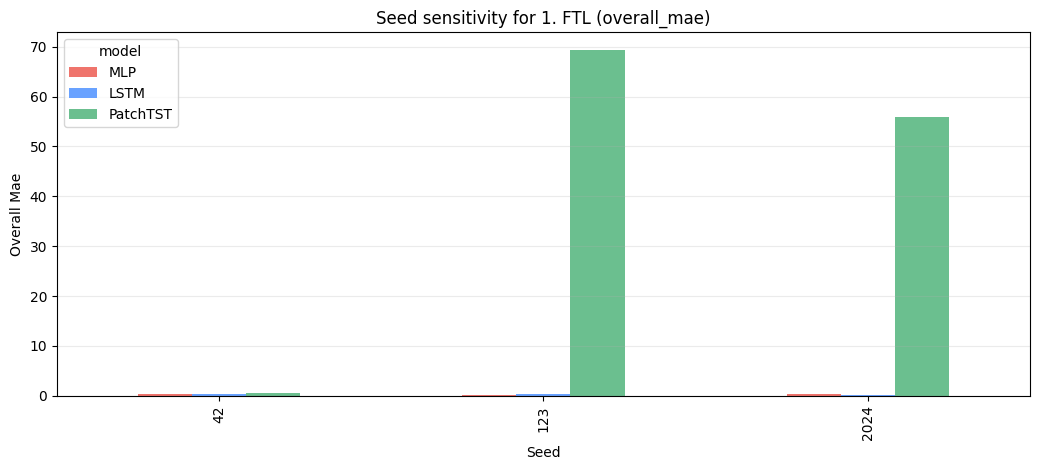

model,seed,MLP,LSTM,PatchTST
0,42,0.318187,0.322613,0.472528
1,123,0.230428,0.304517,69.412360
2,2024,0.348348,0.223464,55.960421


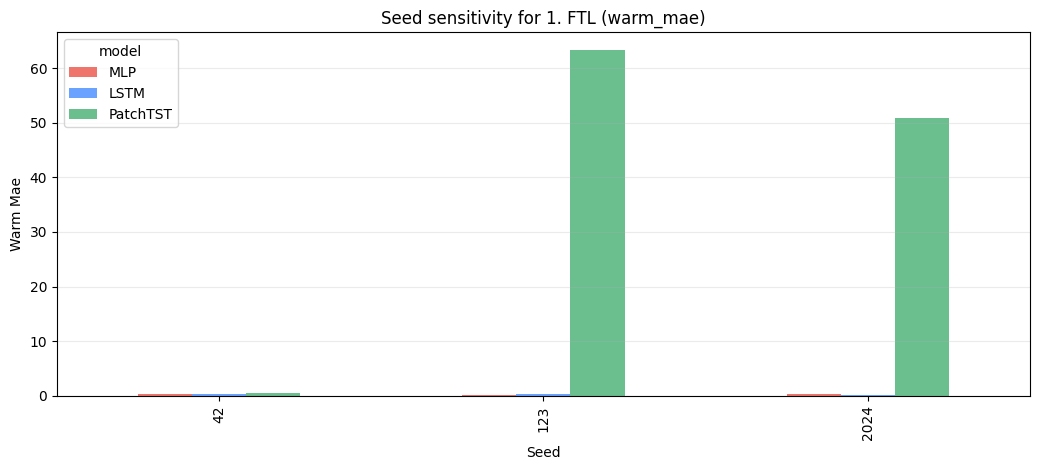

model,seed,MLP,LSTM,PatchTST
0,42,0.312544,0.302968,0.456616
1,123,0.217357,0.292606,63.392644
2,2024,0.336664,0.213984,50.872551


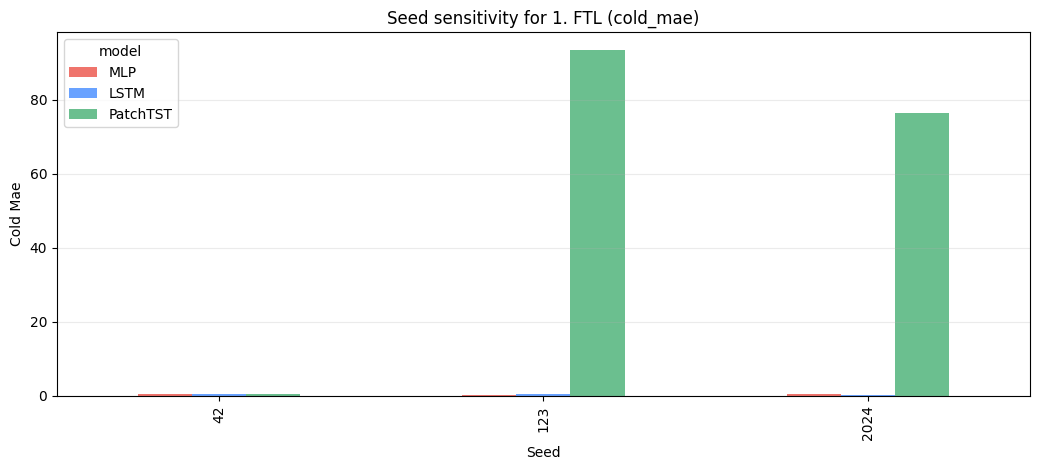

model,seed,MLP,LSTM,PatchTST
0,42,0.340757,0.401195,0.536173
1,123,0.282713,0.352159,93.491224
2,2024,0.395083,0.261382,76.311901


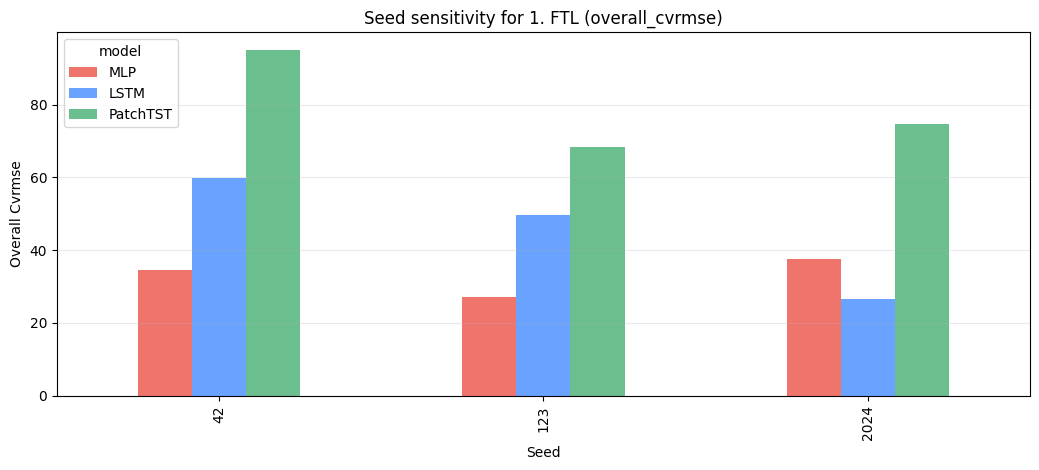

model,seed,MLP,LSTM,PatchTST
0,42,34.639142,59.792459,95.150734
1,123,27.136162,49.796799,68.478973
2,2024,37.646467,26.566649,74.737602


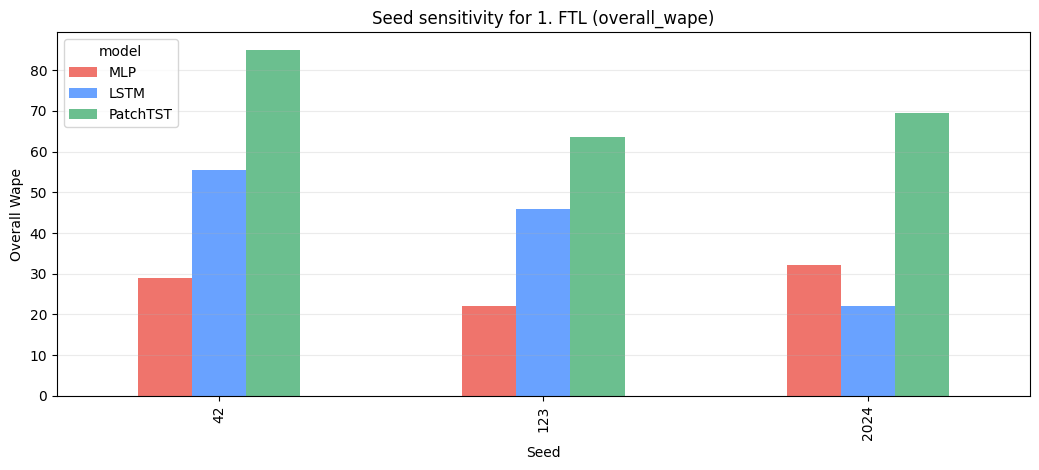

model,seed,MLP,LSTM,PatchTST
0,42,29.053653,55.545916,85.086090
1,123,21.965069,45.853382,63.605312
2,2024,32.043992,21.948485,69.471916


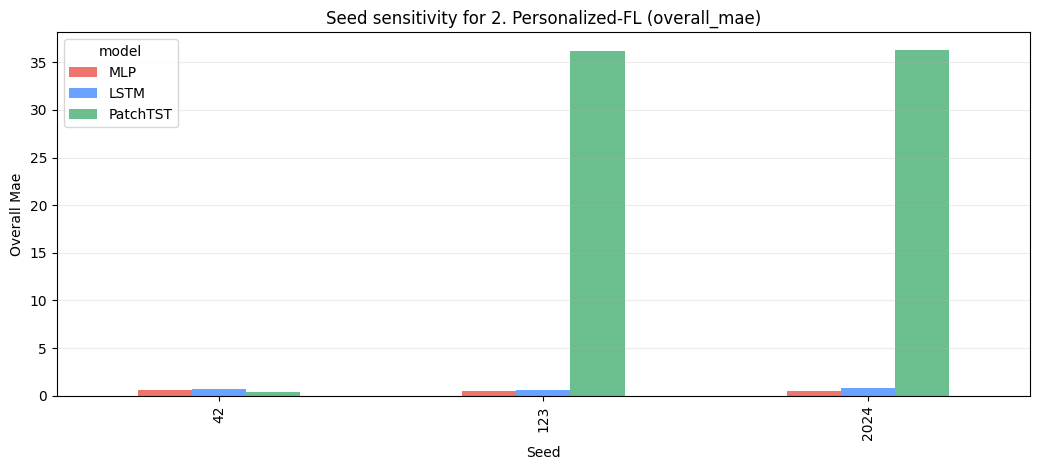

model,seed,MLP,LSTM,PatchTST
0,42,0.572855,0.670397,0.354593
1,123,0.514172,0.624646,36.189131
2,2024,0.484080,0.794621,36.326560


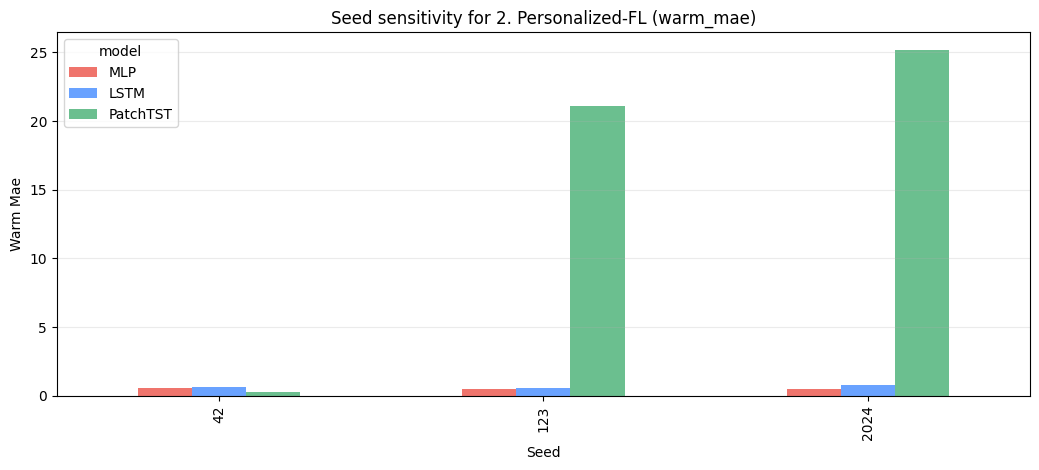

model,seed,MLP,LSTM,PatchTST
0,42,0.572030,0.601822,0.263504
1,123,0.498676,0.565053,21.106261
2,2024,0.471386,0.807416,25.199582


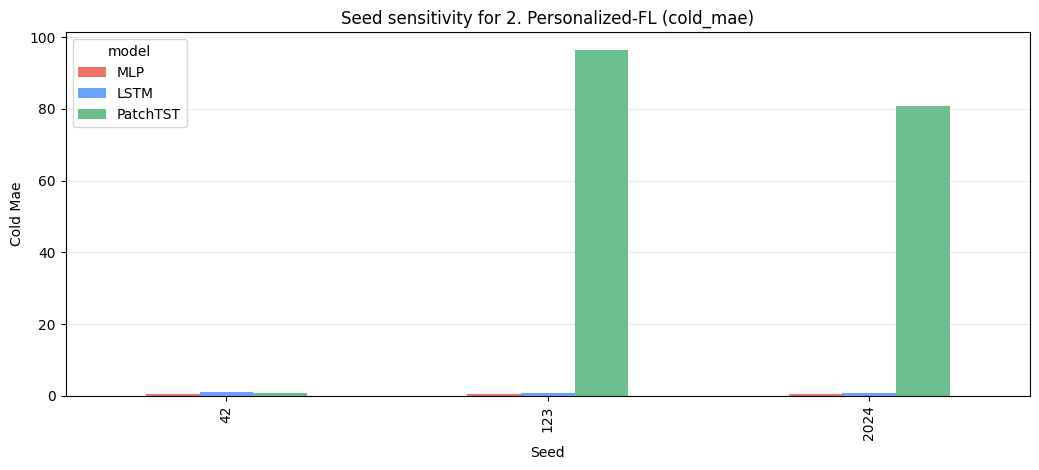

model,seed,MLP,LSTM,PatchTST
0,42,0.576155,0.944699,0.718947
1,123,0.576155,0.863016,96.520611
2,2024,0.534856,0.743442,80.834471


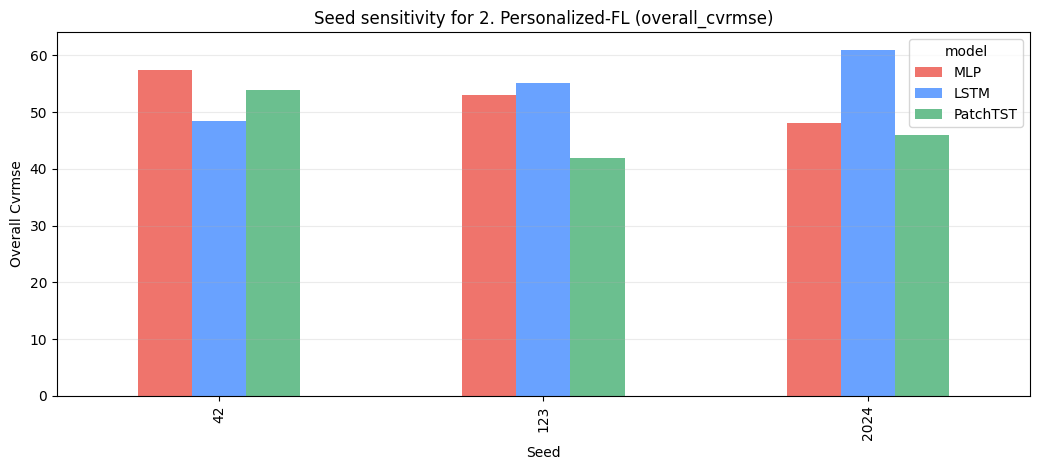

model,seed,MLP,LSTM,PatchTST
0,42,57.425093,48.525902,53.968521
1,123,53.090950,55.110657,41.891605
2,2024,48.086855,61.021839,46.005383


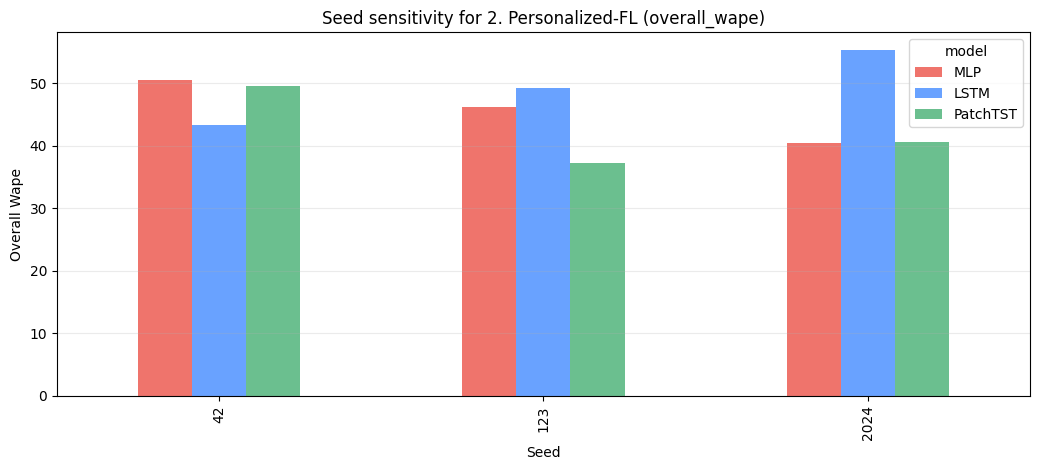

model,seed,MLP,LSTM,PatchTST
0,42,50.526504,43.336353,49.596451
1,123,46.216831,49.259319,37.186283
2,2024,40.477661,55.384224,40.560715


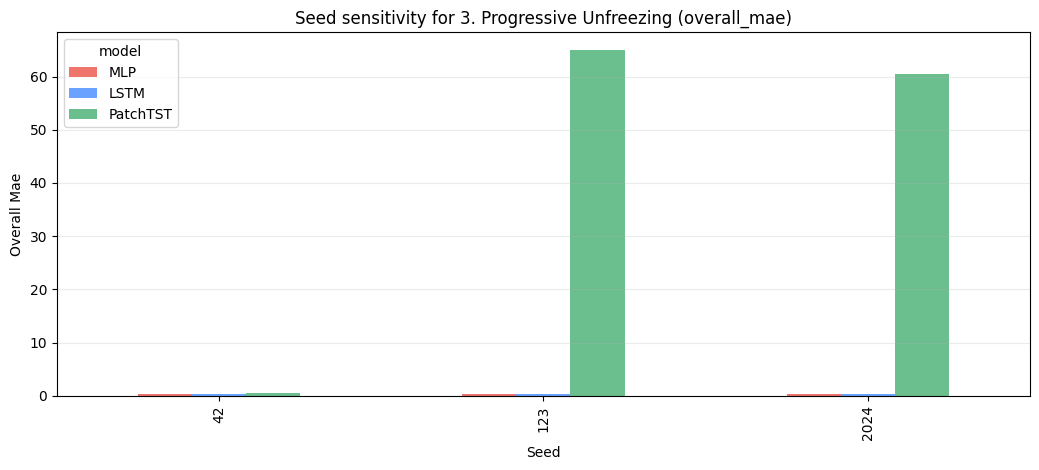

model,seed,MLP,LSTM,PatchTST
0,42,0.287381,0.301755,0.482944
1,123,0.349383,0.352255,65.066794
2,2024,0.257995,0.246869,60.553543


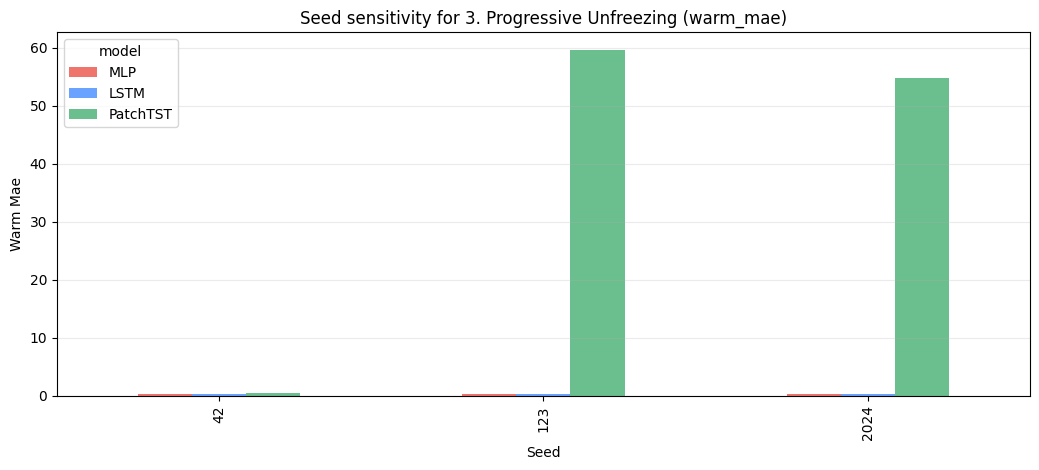

model,seed,MLP,LSTM,PatchTST
0,42,0.285010,0.287711,0.468439
1,123,0.343846,0.340415,59.679998
2,2024,0.252999,0.235218,54.782612


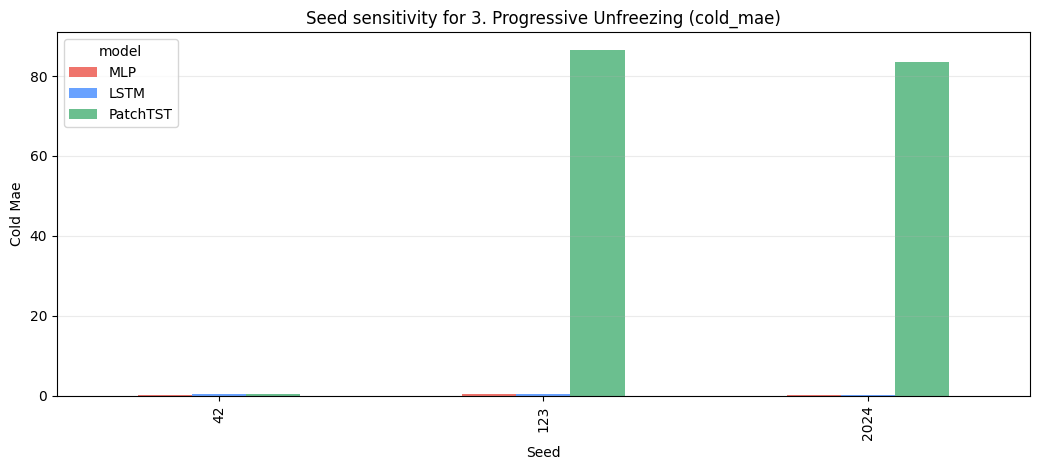

model,seed,MLP,LSTM,PatchTST
0,42,0.296862,0.357928,0.540966
1,123,0.371534,0.399613,86.613975
2,2024,0.277980,0.293475,83.637266


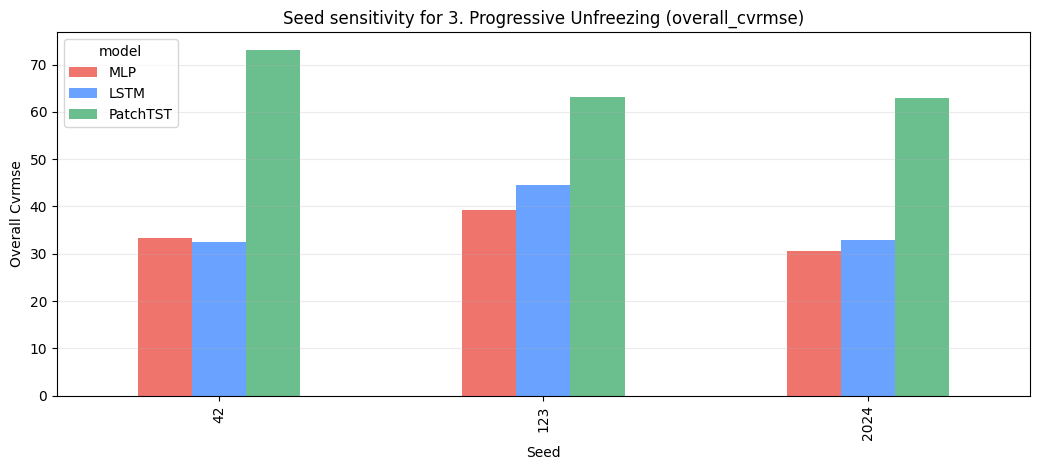

model,seed,MLP,LSTM,PatchTST
0,42,33.281174,32.449451,73.149666
1,123,39.207580,44.640957,63.190041
2,2024,30.647620,32.858228,62.989445


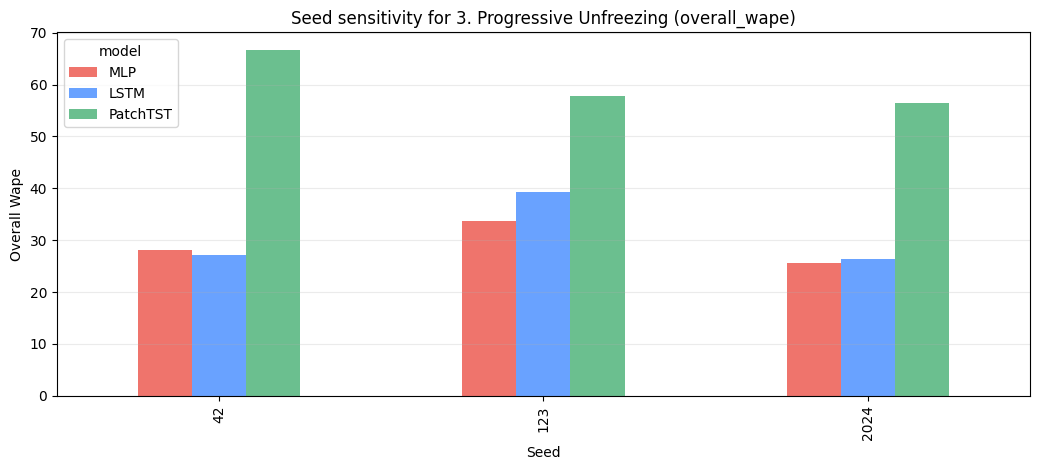

model,seed,MLP,LSTM,PatchTST
0,42,28.177068,27.073854,66.746315
1,123,33.705105,39.280071,57.849564
2,2024,25.685776,26.368556,56.486160


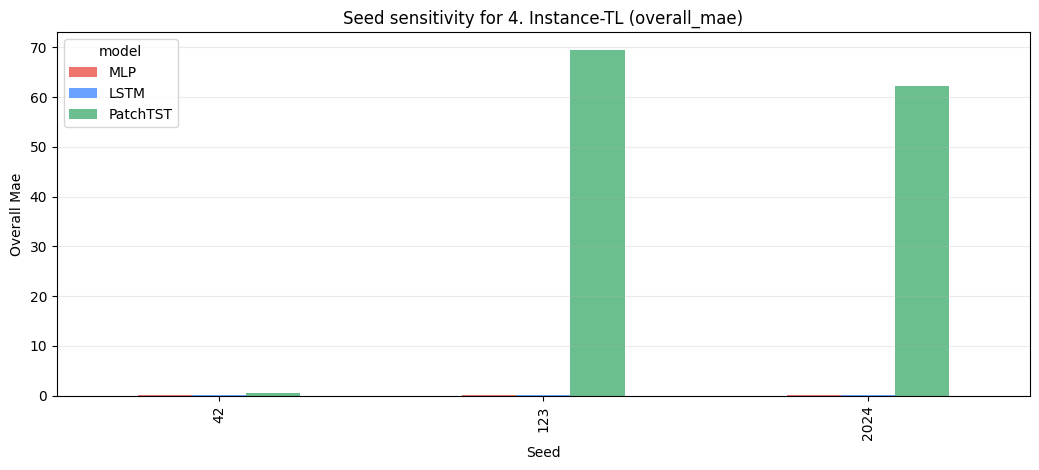

model,seed,MLP,LSTM,PatchTST
0,42,0.169222,0.156367,0.486494
1,123,0.158298,0.105528,69.525614
2,2024,0.155279,0.127835,62.250609


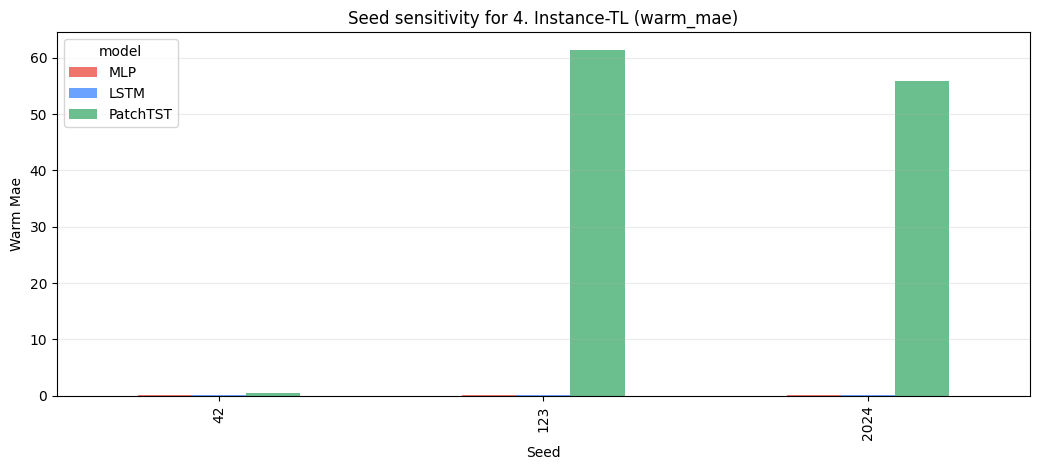

model,seed,MLP,LSTM,PatchTST
0,42,0.176903,0.146867,0.456851
1,123,0.165333,0.101744,61.462070
2,2024,0.151545,0.120376,55.846004


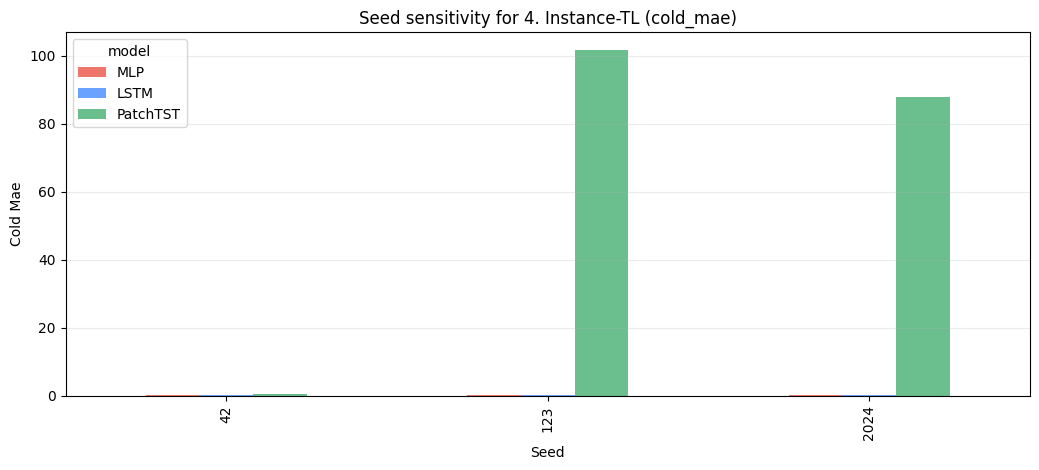

model,seed,MLP,LSTM,PatchTST
0,42,0.138499,0.194365,0.605066
1,123,0.130159,0.120663,101.779789
2,2024,0.170216,0.157671,87.869028


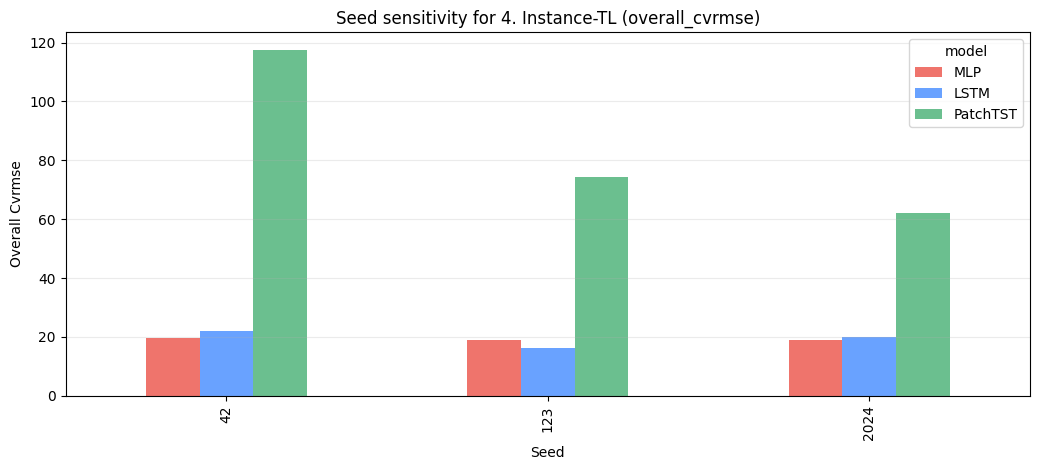

model,seed,MLP,LSTM,PatchTST
0,42,19.676574,22.073579,117.595261
1,123,18.954069,16.285570,74.347916
2,2024,19.032662,20.031262,62.230522


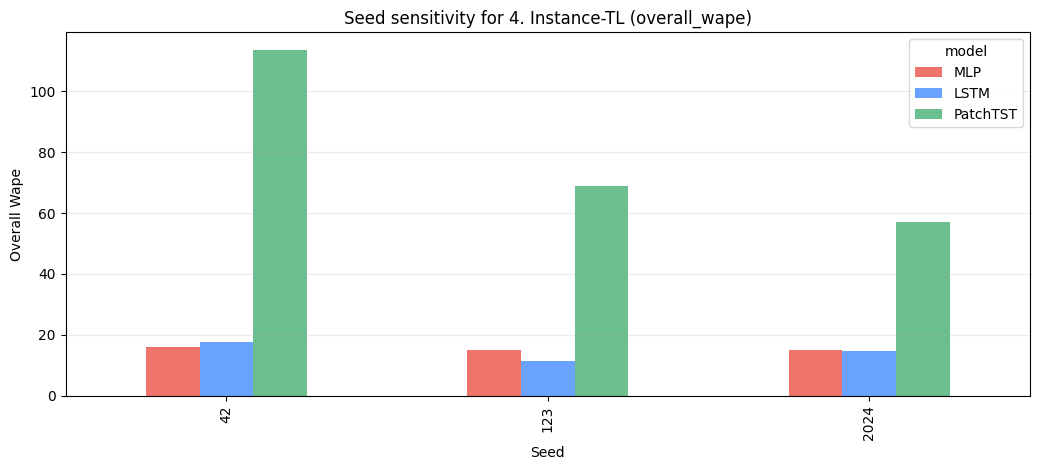

model,seed,MLP,LSTM,PatchTST
0,42,16.018918,17.513251,113.715179
1,123,15.016095,11.394102,68.940773
2,2024,15.075167,14.821021,57.030045


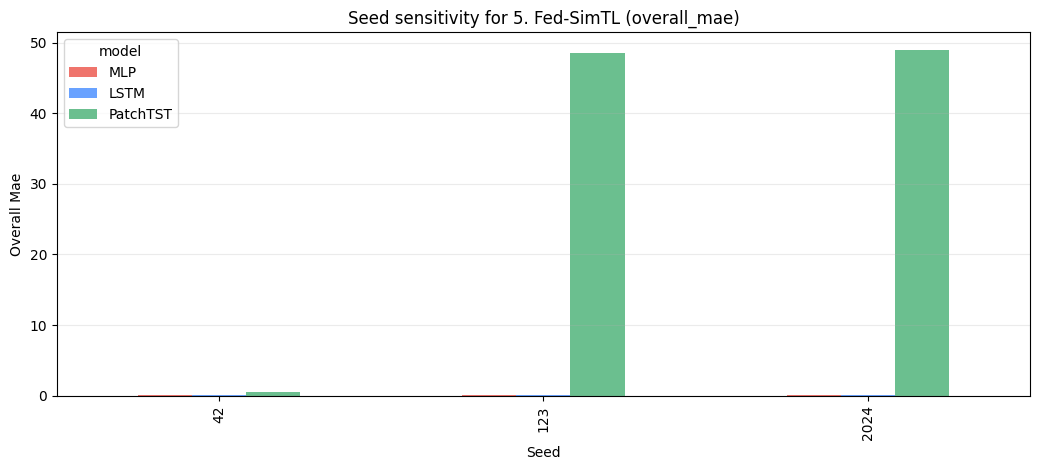

model,seed,MLP,LSTM,PatchTST
0,42,0.150183,0.117393,0.494479
1,123,0.154082,0.113728,48.529742
2,2024,0.146217,0.123873,49.011650


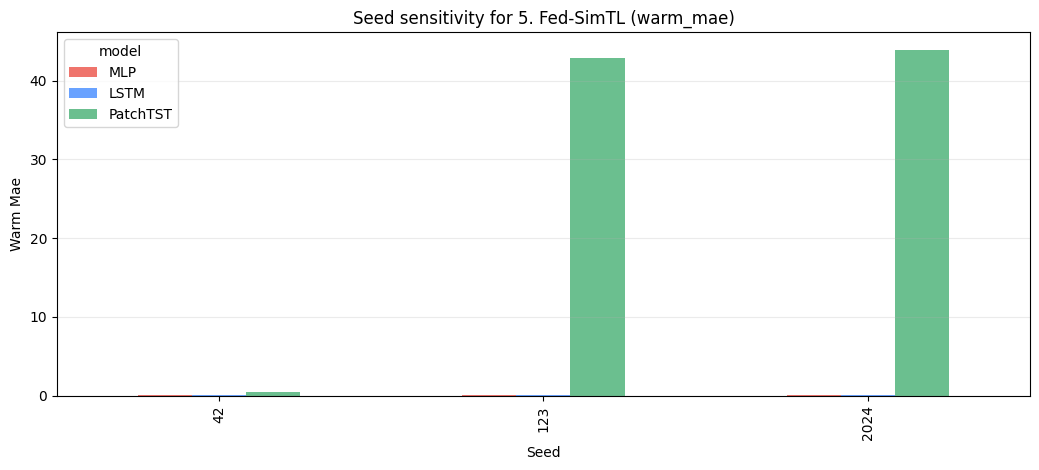

model,seed,MLP,LSTM,PatchTST
0,42,0.145514,0.110654,0.489853
1,123,0.151728,0.101674,42.824069
2,2024,0.154516,0.114802,43.919345


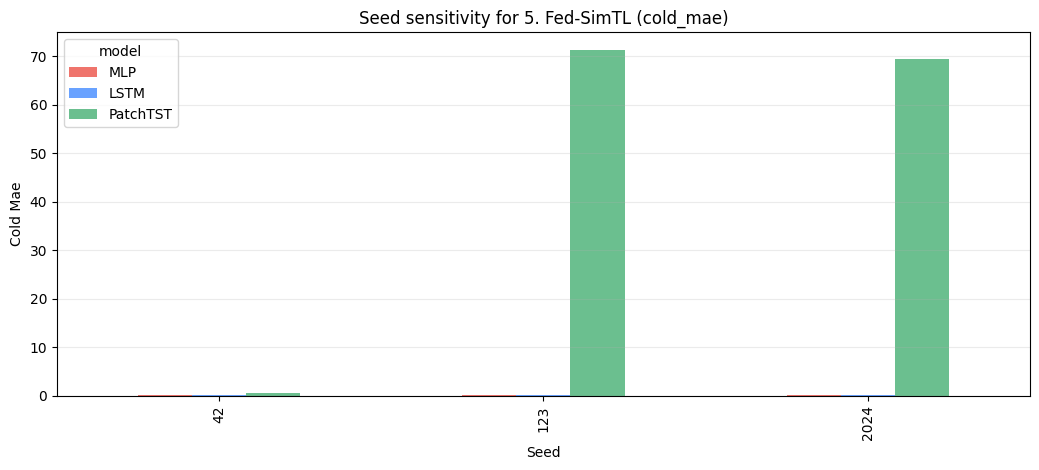

model,seed,MLP,LSTM,PatchTST
0,42,0.168858,0.144346,0.512985
1,123,0.163496,0.161942,71.352435
2,2024,0.113021,0.160160,69.380866


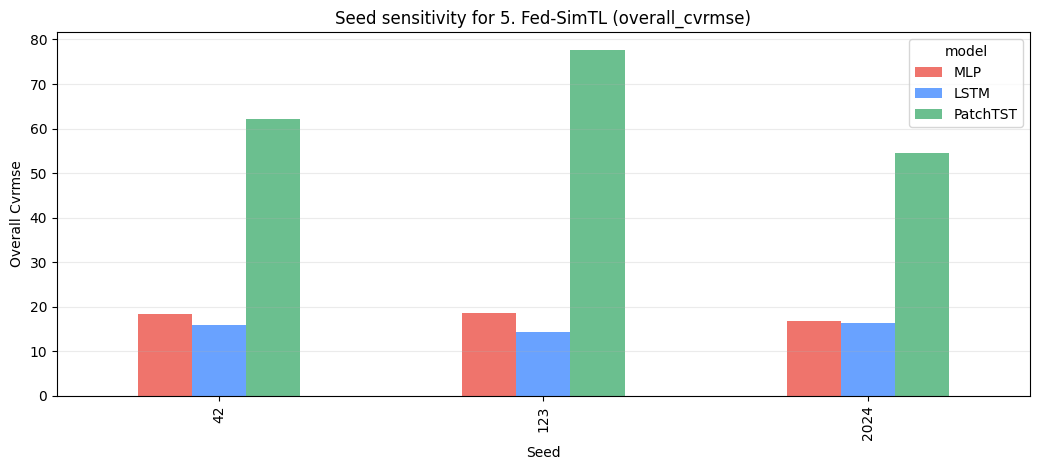

model,seed,MLP,LSTM,PatchTST
0,42,18.412348,15.951449,62.194717
1,123,18.632132,14.312796,77.721489
2,2024,16.800215,16.250704,54.525322


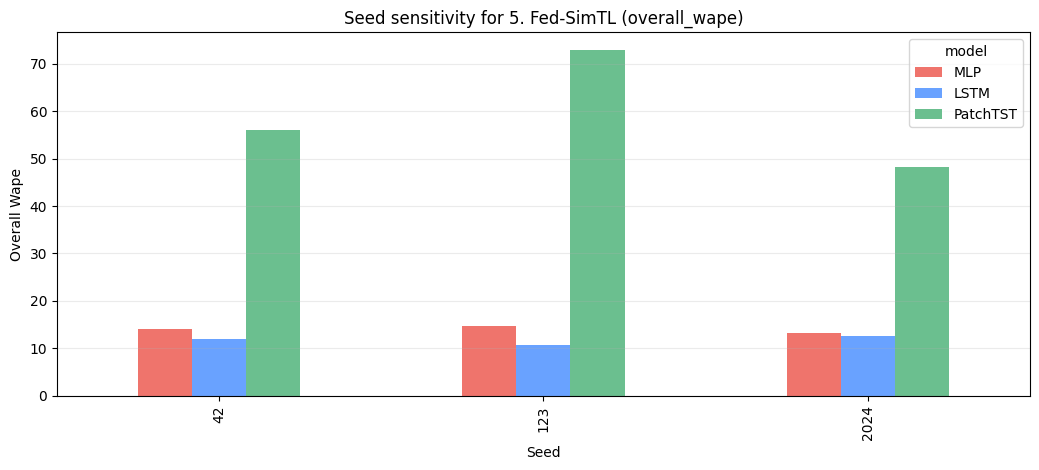

model,seed,MLP,LSTM,PatchTST
0,42,14.158681,12.060270,56.152409
1,123,14.696657,10.798671,72.999672
2,2024,13.271740,12.533323,48.299549


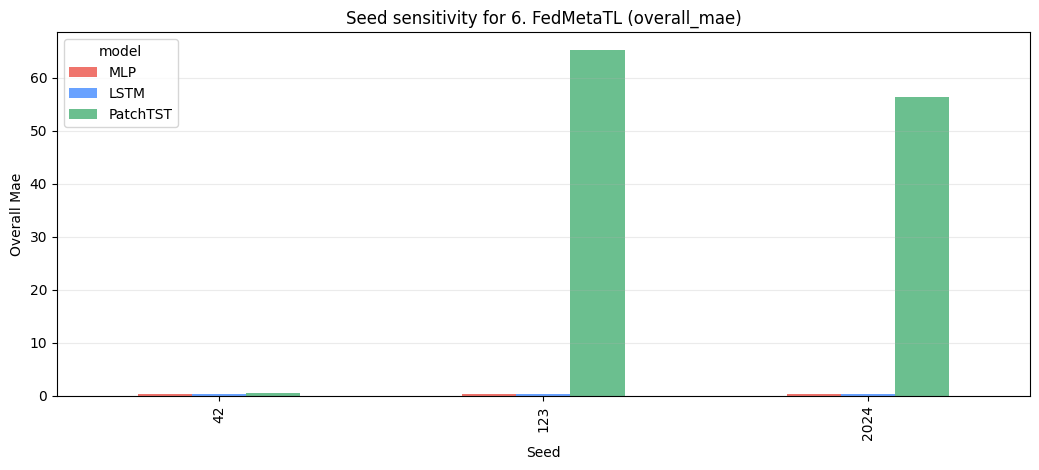

model,seed,MLP,LSTM,PatchTST
0,42,0.272462,0.249723,0.497350
1,123,0.334010,0.356371,65.338018
2,2024,0.312235,0.258813,56.404747


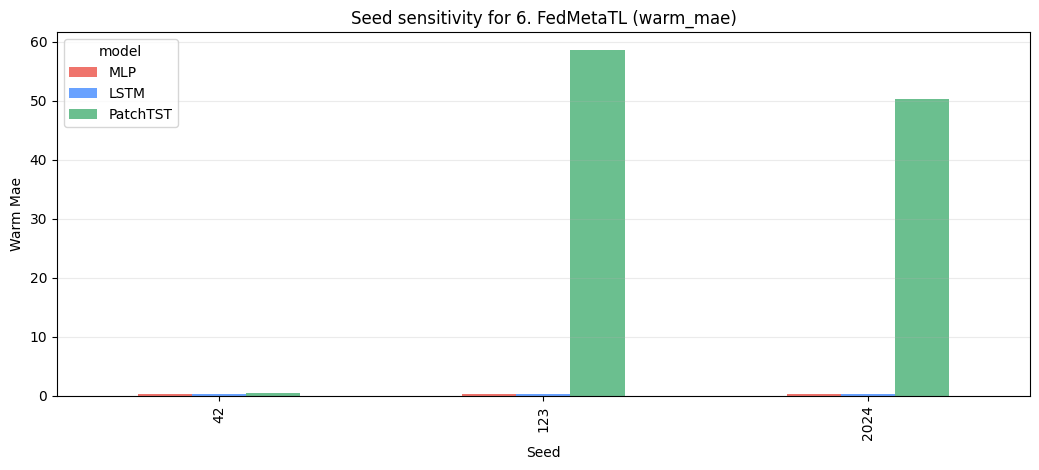

model,seed,MLP,LSTM,PatchTST
0,42,0.266884,0.236948,0.478360
1,123,0.332701,0.338498,58.655160
2,2024,0.304806,0.254592,50.311975


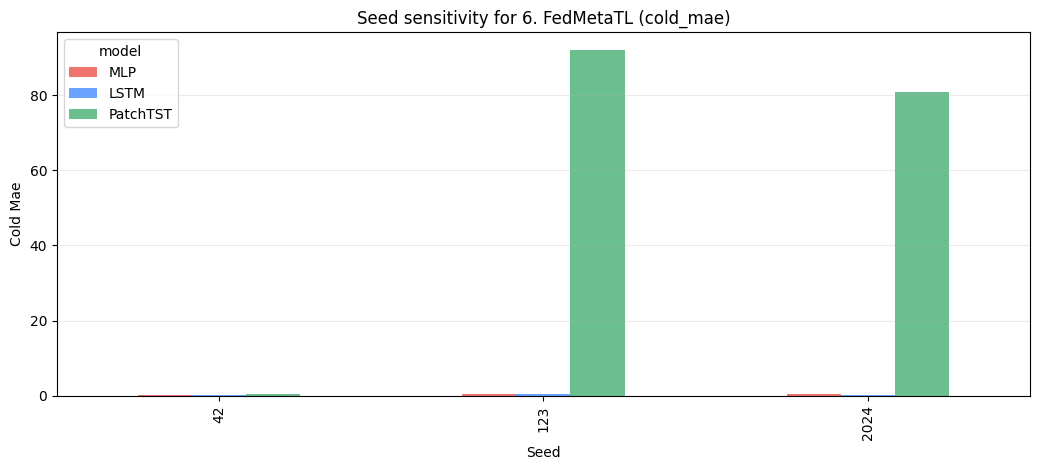

model,seed,MLP,LSTM,PatchTST
0,42,0.294777,0.300822,0.573312
1,123,0.339243,0.427863,92.069449
2,2024,0.341948,0.275694,80.775836


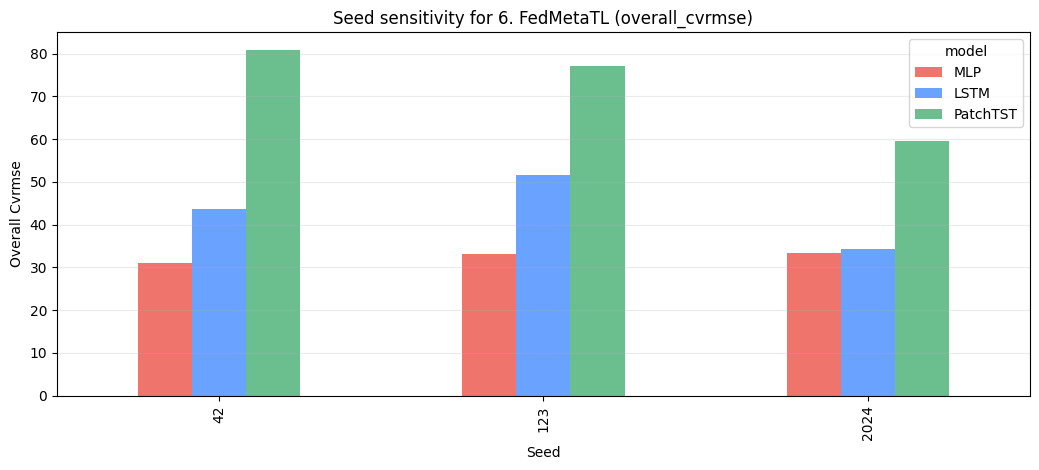

model,seed,MLP,LSTM,PatchTST
0,42,31.062429,43.691177,80.951653
1,123,33.247933,51.634724,77.071571
2,2024,33.415516,34.301277,59.688145


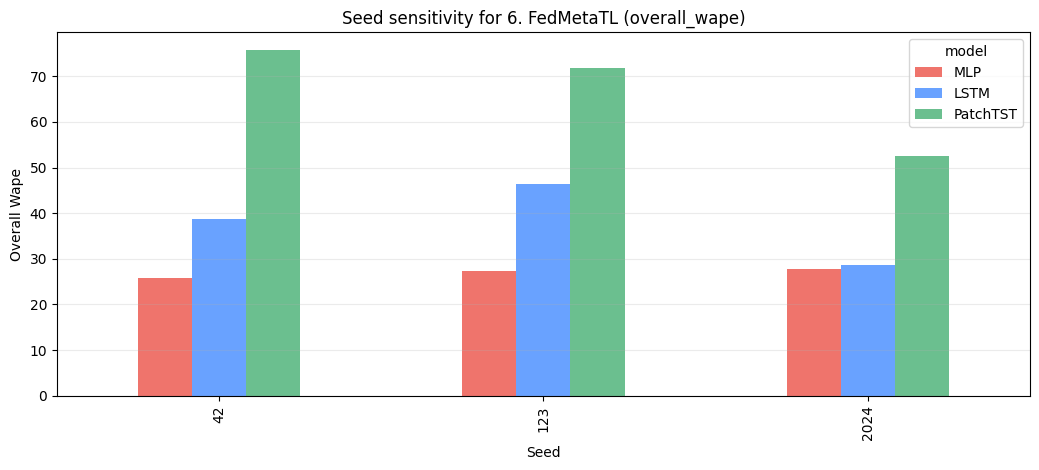

model,seed,MLP,LSTM,PatchTST
0,42,25.831858,38.766674,75.850014
1,123,27.279778,46.392658,71.787834
2,2024,27.866697,28.612213,52.472401


In [7]:
# Seed sensitivity plots for all strategies and all metrics

for strategy in DISPLAY_STRATEGIES:

    for metric in METRICS:

        d = all_seed_results[
            all_seed_results['strategy'] == strategy
        ].copy()

        if d.empty:
            print(f'No rows for strategy: {strategy}')
            continue

        d = d[d['seed'].isin(SEEDS)].sort_values(['seed', 'model'])

        pivot = d.pivot_table(
            index='seed',
            columns='model',
            values=metric,
            aggfunc='mean'
        )

        preferred_order = ['MLP', 'LSTM', 'PatchTST']

        existing_cols = [c for c in preferred_order if c in pivot.columns]
        pivot = pivot[existing_cols]

        pivot.plot(
            kind='bar',
            figsize=(10.5, 4.8),
            color=['#ef746c', '#69a2ff', '#6bbf8f'][:len(existing_cols)]
        )

        plt.title(
            f'Seed sensitivity for {strategy} ({metric})'
        )

        plt.xlabel('Seed')

        plt.ylabel(
            metric.replace('_', ' ').title()
        )

        plt.grid(axis='y', alpha=0.25)

        plt.tight_layout()
        plt.show()

        display(pivot.reset_index())

## How To Run
1. In each model notebook, set `SEED` (e.g. `SEED=42`), run training/evaluation, then run the final standardized export cell.
2. Repeat for all seeds in `SEEDS`.
3. Run this notebook to aggregate and plot.


In [8]:
# Ablation table: FTL vs key variants (seed-aware)
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("saved_results")
RESULTS_DIR.mkdir(exist_ok=True)

MODEL_ORDER = ["MLP", "LSTM", "PatchTST"]
COMPARISONS = [
    ("FTL vs No Pretraining", "1b. FedAvg (No Pretrain)"),
    ("FTL vs Personalized-FL", "2. Personalized-FL"),
    ("FTL vs FedMetaTL", "6. FedMetaTL"),
    ("FTL vs Progressive Unfreezing", "3. Progressive Unfreezing"),
]

def _norm_model(m):
    s = str(m).upper()
    if s == "PATCHTST":
        return "PatchTST"
    if s == "LSTM":
        return "LSTM"
    if s == "MLP":
        return "MLP"
    return str(m)

df = all_seed_results.copy()
df["model"] = df["model"].map(_norm_model)
df["seed"] = df["seed"].astype(int)

rows = []
for model in MODEL_ORDER:
    dm = df[df["model"] == model].copy()
    if dm.empty:
        continue

    ftl = dm[dm["strategy"] == "1. FTL"][["seed", "cold_mae"]].rename(columns={"cold_mae": "ftl_cold"})
    if ftl.empty:
        continue

    for label, comp_strategy in COMPARISONS:
        comp = dm[dm["strategy"] == comp_strategy][["seed", "cold_mae"]].rename(columns={"cold_mae": "comp_cold"})
        if comp.empty:
            continue

        merged = pd.merge(ftl, comp, on="seed", how="inner")
        if merged.empty:
            continue

        seeds_used = sorted(merged["seed"].unique().tolist())
        ftl_mean = float(merged["ftl_cold"].mean())
        comp_mean = float(merged["comp_cold"].mean())

        if comp_mean == 0:
            rel_txt = "N/A"
        else:
            rel_pct = abs(ftl_mean - comp_mean) / abs(comp_mean) * 100.0
            rel_txt = f"{rel_pct:.1f}% {'lower' if ftl_mean < comp_mean else 'higher'}"

        rows.append({
            "Model": model,
            "Seeds": ", ".join(str(s) for s in seeds_used),
            "Comparison": label,
            "FTL Cold MAE": round(ftl_mean, 3),
            "Comparator Cold MAE": round(comp_mean, 3),
            "Relative Change of FTL": rel_txt,
        })

ablation_df = pd.DataFrame(rows)
ablation_df["Model"] = pd.Categorical(ablation_df["Model"], categories=MODEL_ORDER, ordered=True)
ablation_df = ablation_df.sort_values(["Model", "Comparison"]).reset_index(drop=True)
ablation_df["Model"] = ablation_df["Model"].astype(str)

display(ablation_df)

csv_path = RESULTS_DIR / "ablation_ftl_vs_variants.csv"
tex_path = RESULTS_DIR / "ablation_ftl_vs_variants.tex"

ablation_df.to_csv(csv_path, index=False)

latex_df = ablation_df.copy()
with open(tex_path, "w", encoding="utf-8") as f:
    f.write("\\begin{table}[htbp]\n\\centering\n")
    f.write("\\caption{Ablation: FTL compared with related variants (Cold MAE, mean over shared seeds).}\n")
    f.write("\\label{tab:ablation_ftl_variants}\n")
    f.write("\\begin{tabular}{lllccc}\n\\hline\n")
    f.write("Model & Seeds & Comparison & FTL Cold MAE & Comparator Cold MAE & Relative Change of FTL \\\\ \\hline\n")
    for _, r in latex_df.iterrows():
        f.write(f"{r['Model']} & {r['Seeds']} & {r['Comparison']} & {r['FTL Cold MAE']:.3f} & {r['Comparator Cold MAE']:.3f} & {r['Relative Change of FTL']} \\\\\n")
    f.write("\\hline\n\\end{tabular}\n\\end{table}\n")

print("Saved:", csv_path)
print("Saved:", tex_path)

,Model,Seeds,Comparison,FTL Cold MAE,Comparator Cold MAE,Relative Change of FTL
0,MLP,"42, 123, 2024",FTL vs FedMetaTL,0.340,0.325,4.4% higher
1,MLP,"42, 123, 2024",FTL vs No Pretraining,0.340,0.393,13.6% lower
2,MLP,"42, 123, 2024",FTL vs Personalized-FL,0.340,0.562,39.6% lower
3,MLP,"42, 123, 2024",FTL vs Progressive Unfreezing,0.340,0.315,7.6% higher
4,LSTM,"42, 123, 2024",FTL vs FedMetaTL,0.338,0.335,1.0% higher
5,LSTM,"42, 123, 2024",FTL vs No Pretraining,0.338,0.584,42.0% lower
6,LSTM,"42, 123, 2024",FTL vs Personalized-FL,0.338,0.850,60.2% lower
7,LSTM,"42, 123, 2024",FTL vs Progressive Unfreezing,0.338,0.350,3.5% lower
8,PatchTST,"42, 123, 2024",FTL vs FedMetaTL,56.780,57.806,1.8% lower
9,PatchTST,"42, 123, 2024",FTL vs No Pretraining,56.780,80.159,29.2% lower


Saved: saved_results\ablation_ftl_vs_variants.csv
Saved: saved_results\ablation_ftl_vs_variants.tex
